In [6]:
import numpy as np
import math
import matplotlib.pyplot as plt
from numba import njit

In [42]:
def energy(s, J, h):
    #2D Ising energy with periodic boundary conditions.
    
    E = 0.0
    N = s.shape[0]

    for i in range(N):
        for j in range(N):
            E -= J * s[i, j] * (
                s[(i + 1) % N, j] +
                s[i, (j + 1) % N]
            )
            E -= h * s[i, j]

    return E

@njit
def sweep_once(s, N, J, h, T, E):
    for _ in range(N * N):
        x = np.random.randint(N)
        y = np.random.randint(N)

        nn = (
            s[(x + 1) % N, y] +
            s[(x - 1) % N, y] +
            s[x, (y + 1) % N] +
            s[x, (y - 1) % N]
        )

        dE = 2 * s[x, y] * (J * nn + h)

        if dE <= 0 or np.random.rand() < math.exp(-dE / T):
            s[x, y] *= -1
            E += dE

    return E

def two_d_metropolis_ising(N, J, h, T, sweeps, warmup=None):
    if warmup is None:
        warmup = sweeps // 10

    s = np.random.choice(np.array([-1, 1]), size=(N, N))

    E = energy(s, J, h)

    # warmup
    for _ in range(warmup):
        E = sweep_once(s, N, J, h, T, E)

    energies = []
    mags = []

    for _ in range(sweeps):
        E = sweep_once(s, N, J, h, T, E)
        energies.append(E)
        mags.append(s.sum())

    return np.array(energies), np.array(mags) , s.copy()

def thermo(energies, mags, J, h, T, N):
    Nspins = N * N

    E = np.mean(energies) / Nspins
    EJ = E / abs(J)

    cv = np.var(energies) / (T**2 * Nspins)

    m = np.mean(np.abs(mags)) / Nspins
    chi = np.var(mags) / (T * Nspins)

    Tc = 2 * abs(J) / np.log(1 + np.sqrt(2))

    return {
        "Tc": Tc,
        "E per spin": E,
        "E per spin wrt J": EJ,
        "cv": cv,
        "m": m,
        "chi": chi
    }

In [44]:
# --------------------------------------------------
# Heat Capacity vs Temperature
# --------------------------------------------------

Nsize = 50
J = -5.0
h = 0.0

temps = np.linspace(3, 20, 200)

cv_mean = []
cv_std = []

n_runs = 5

for T in temps:

    cvs = []

    for _ in range(n_runs):

        energies, mags, _ = two_d_metropolis_ising(
            N=Nsize,
            J=J,
            h=h,
            T=T,
            sweeps=10000,
            warmup=1000
        )

        cv = np.var(energies) / (T**2 * Nsize * Nsize)

        cvs.append(cv)

    cv_mean.append(np.mean(cvs))
    cv_std.append(np.std(cvs))

Tc = 2 * abs(J) / np.log(1 + np.sqrt(2))


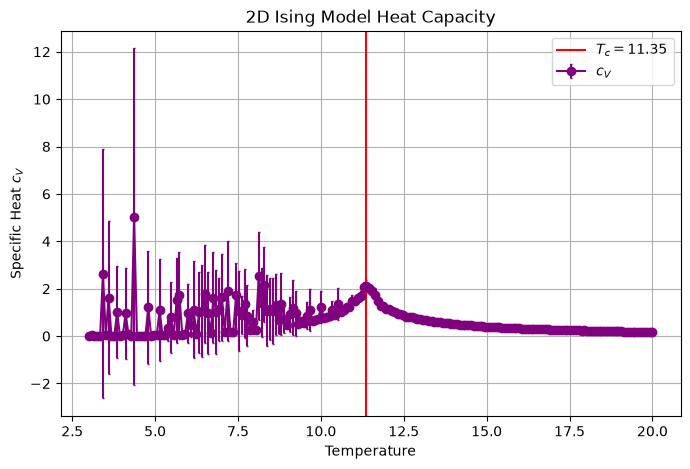

In [56]:
plt.figure(figsize=(8,5))

plt.errorbar(
    temps,
    cv_mean,
    yerr=cv_std,
    fmt='o-',
    capsize=1,
    label=r"$c_V$",
    color='purple',
)

plt.axvline(
    Tc,
    color='red',
    linestyle='-',
    label=fr"$T_c={Tc:.2f}$"
)

plt.xlabel("Temperature")
plt.ylabel(r"Specific Heat $c_V$")
plt.title("2D Ising Model Heat Capacity")
plt.grid(True)
plt.legend()

plt.savefig("cvhighres.pdf")
plt.show()

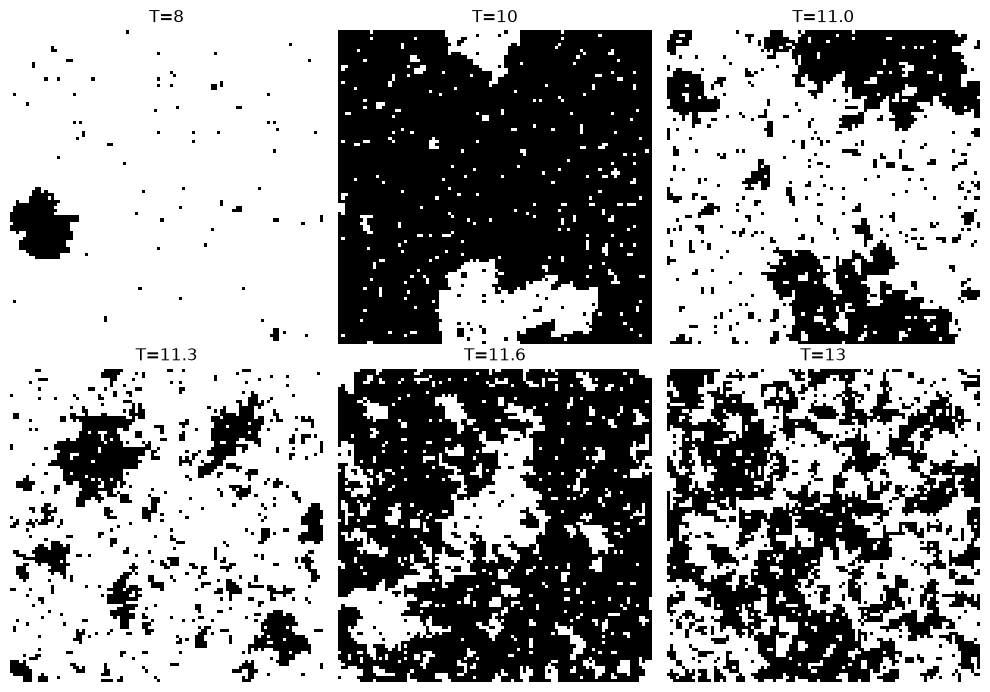

In [41]:
temps = [
    8,
    10,
    11.0,
    11.3,
    11.6,
    13
]

fig, axes = plt.subplots(2, 3, figsize=(10, 7))

for ax, T in zip(axes.flat, temps):

    E, M, state = two_d_metropolis_ising(
        N=100,
        J=5,
        h=0,
        T=T,
        sweeps=1000,
        warmup=100
    )

    ax.imshow(state, cmap="gray", vmin=-1, vmax=1)
    ax.set_title(f"T={T}")
    ax.axis("off")

plt.tight_layout()
plt.show()

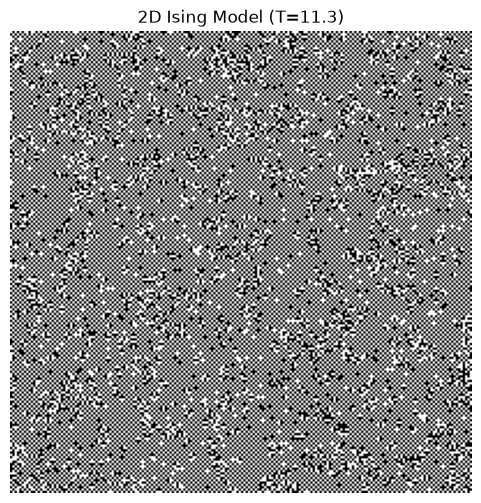

In [ ]:
T = 11.3

E, M, state = two_d_metropolis_ising(
    N=200,
    J=5,
    h=0,
    T=T,
    sweeps=20000,
    warmup=5000
)

plt.figure(figsize=(6, 6))

plt.imshow(state, cmap="gray", vmin=-1, vmax=1)

plt.title(f"2D Ising Model (T={T})")
plt.axis("off")

plt.show()

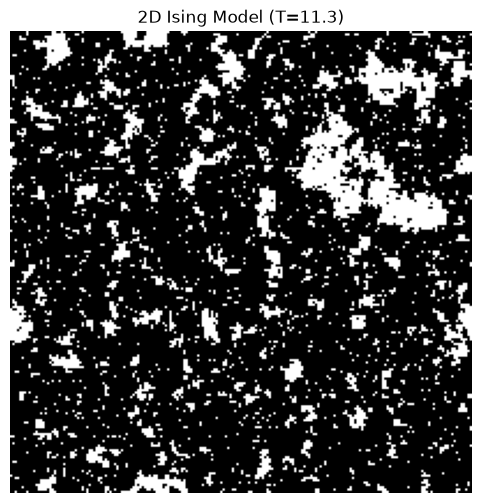

In [39]:
T = 11.3

E, M, state = two_d_metropolis_ising(
    N=200,
    J=5,
    h=0,
    T=T,
    sweeps=20000,
    warmup=5000
)

plt.figure(figsize=(6, 6))

plt.imshow(state, cmap="gray", vmin=-1, vmax=1)

plt.title(f"2D Ising Model (T={T})")
plt.axis("off")

plt.show()

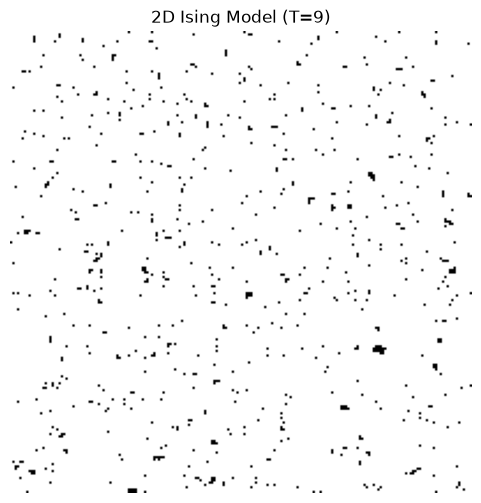

In [40]:
T = 9

E, M, state = two_d_metropolis_ising(
    N=200,
    J=5,
    h=0,
    T=T,
    sweeps=20000,
    warmup=5000
)

plt.figure(figsize=(6, 6))

plt.imshow(state, cmap="gray", vmin=-1, vmax=1)

plt.title(f"2D Ising Model (T={T})")
plt.axis("off")

plt.show()

In [58]:
# --------------------------------------------------
# Heat Capacity vs Temperature
# --------------------------------------------------

Nsize = 50
J = -5.0
h = 0.0

temps = np.linspace(3, 18, 5)

cv_mean = []
cv_std = []

n_runs = 10

for T in temps:

    cvs = []

    for _ in range(n_runs):

        energies, mags, _ = two_d_metropolis_ising(
            N=Nsize,
            J=J,
            h=h,
            T=T,
            sweeps=10000,
            warmup=1000
        )

        cv = np.var(energies) / (T**2 * Nsize * Nsize)

        cvs.append(cv)

    cv_mean.append(np.mean(cvs))
    cv_std.append(np.std(cvs))

Tc = 2 * abs(J) / np.log(1 + np.sqrt(2))


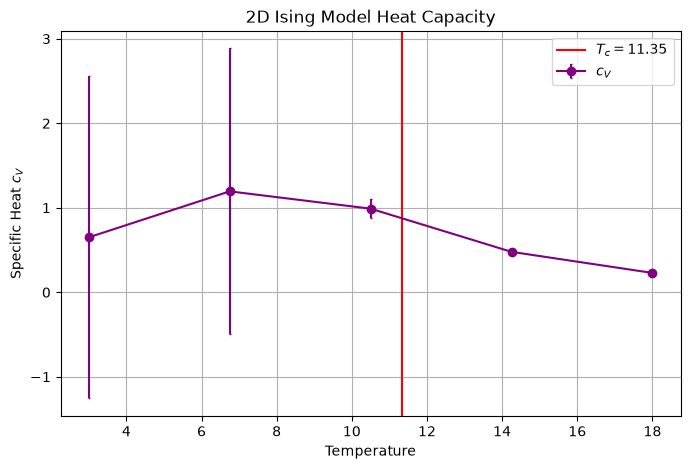

In [59]:
plt.figure(figsize=(8,5))

plt.errorbar(
    temps,
    cv_mean,
    yerr=cv_std,
    fmt='o-',
    capsize=1,
    label=r"$c_V$",
    color='purple',
)

plt.axvline(
    Tc,
    color='red',
    linestyle='-',
    label=fr"$T_c={Tc:.2f}$"
)

plt.xlabel("Temperature")
plt.ylabel(r"Specific Heat $c_V$")
plt.title("2D Ising Model Heat Capacity")
plt.grid(True)
plt.legend()

plt.savefig("cvhighres.pdf")
plt.show()